# **PRACTICAL - 7**

## **Aim: Multivariate & High-Dimensional Data Visualization**

### **Objective:**

*  To understand principles of effective visualization and chart selection strategies
*  To visualize multivariate relationships in data
*  To explore high-dimensional data patterns using t-SNE
*  To interpret insights from complex datasets




**Dataset:** https://archive.ics.uci.edu/ml/datasets/wine+quality

### **Task**
*  Load and preprocess the Wine Quality dataset
*  Apply Principles of Effective Visualization (clarity, simplicity, accuracy)
*  Perform the following visualizations:
*  Scatter Plot Matrix (pairwise feature relationships)
*  Correlation Heatmap
*  Bubble Plot (feature vs feature with quality as size)
*  Parallel Coordinate Plot (multi-feature comparison)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **1 : Import & Install**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

### **2 : Download and Load Dataset (kagglehub)**
We download the dataset directly from Kaggle using `kagglehub` and read the CSV file.

In [8]:
# load red wine dataset
red = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Pract_7/winequality-red.csv', sep=';')

# load white wine dataset
white = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Pract_7/winequality-white.csv', sep=';')

# add type column
red['type'] = 'red'
white['type'] = 'white'

# combine datasets
data = pd.concat([red, white], ignore_index=True)

data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


### **3 : Basic Data Check**

In [9]:
print(data.shape)
print(data.info())
print(data.isnull().sum())

(6497, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB
None
fixed acidity           0
volatile acidity     

### **4 : Basic Preprocessing**

In [13]:
# convert type to numeric
data['type'] = data['type'].map({'red': 0, 'white': 1})

# split features and target
X = data.drop('quality', axis=1)
y = data['quality']

### **5 : Pairplot for selected features**

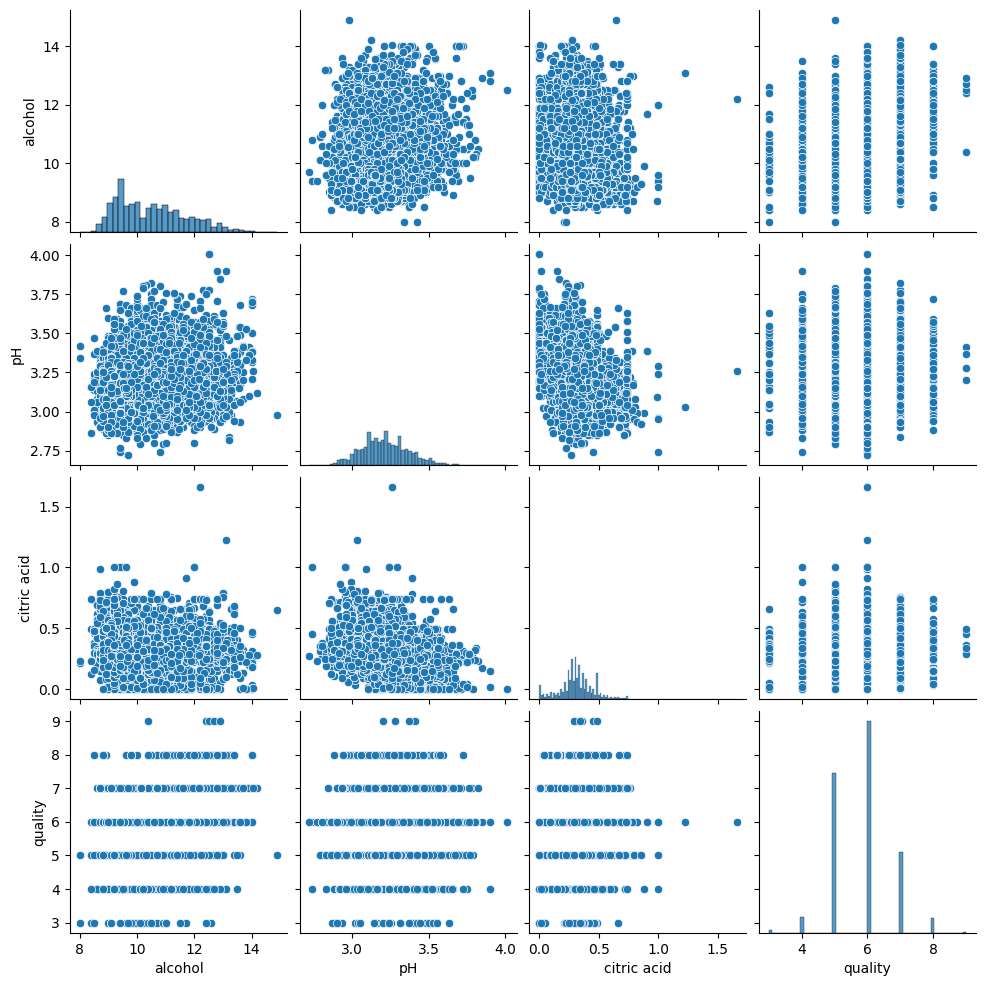

In [17]:
cols = ['alcohol', 'pH', 'citric acid', 'quality']

sns.pairplot(data[cols])
plt.show()

### **6 : Correlation Heatmap**

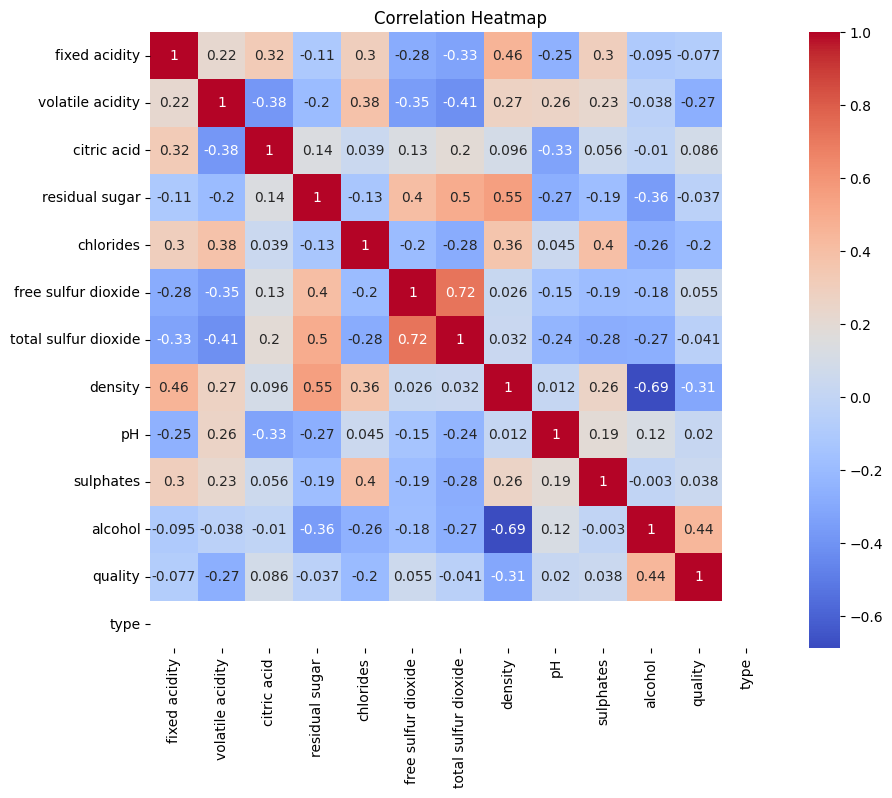

In [19]:
plt.figure(figsize=(10,8))

sns.heatmap(data.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

### **7 : Bubble plot (alcohol vs acidity, size = quality)**

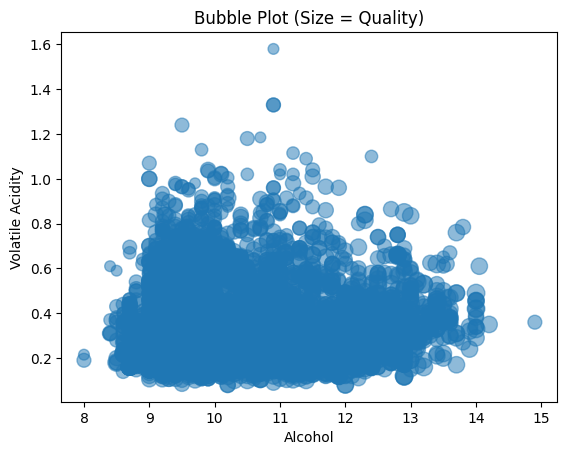

In [21]:
plt.figure()
plt.scatter(
    data['alcohol'],
    data['volatile acidity'],
    s=data['quality']*20,
    alpha=0.5
)

plt.xlabel('Alcohol')
plt.ylabel('Volatile Acidity')
plt.title('Bubble Plot (Size = Quality)')
plt.show()

### **8 : Parallel Coordinates Plot**

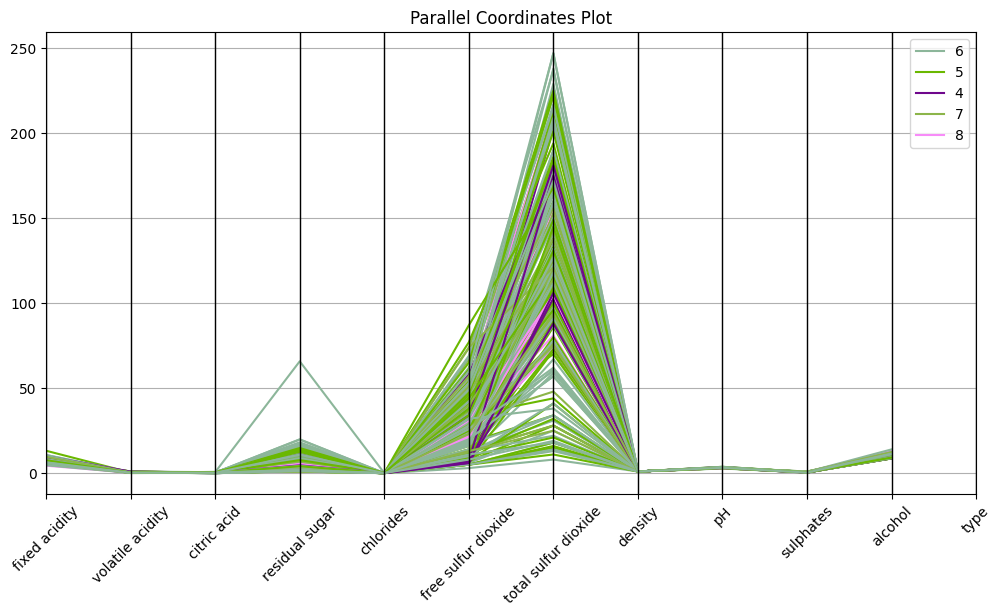

In [22]:
from pandas.plotting import parallel_coordinates

df_parallel = data.copy()
df_parallel['quality'] = df_parallel['quality'].astype(str)

plt.figure(figsize=(12,6))

parallel_coordinates(df_parallel.sample(200), 'quality')

plt.xticks(rotation=45)
plt.title("Parallel Coordinates Plot")

plt.show()

### **9 : Prepare Data for t-SNE**

In [26]:
# separate features
X = data.drop(['quality', 'type'], axis=1)

# scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### **10 : Apply t-SNE**

In [27]:
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

### **11 : Plot t-SNE result**

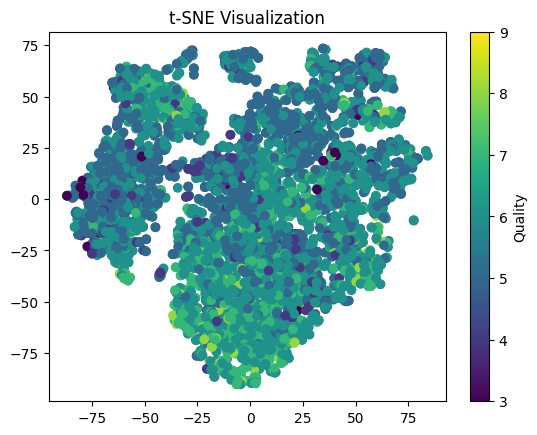

In [28]:
plt.figure()
plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=data['quality'],
    cmap='viridis'
)

plt.colorbar(label='Quality')
plt.title('t-SNE Visualization')
plt.show()

###**Analysis**

- Alcohol shows a positive effect on wine quality  
- Volatile acidity shows a negative effect  
- Most features have weak to moderate relationships  

- Bubble plot indicates higher quality wines have higher alcohol  
- Parallel plot shows similar patterns for high-quality wines  

- t-SNE shows clusters with some overlap  
- Quality depends on multiple features

### **Conclusion :**
*  Pairplot shows relationships between features
*  Heatmap identifies strong correlations
*  Bubble plot adds third dimension (quality)
*  Parallel coordinates help compare multiple features
*  t-SNE reduces high-dimensional data into 2D for visualization